<a href="https://colab.research.google.com/github/yurayura3812-svg/clocr/blob/main/app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install mediapipe -q
!pip install japanize-matplotlib -q

import matplotlib
import matplotlib.font_manager as fm

# japanize-matplotlibが持っているIPAフォントを直接指定
font_path = [f for f in fm.findSystemFonts() if 'ipaexg' in f.lower() or 'ipag' in f.lower()]
if font_path:
    fm.fontManager.addfont(font_path[0])
    matplotlib.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()

【1】服装の写真をアップロードしてください。


Saving スクリーンショット 2026-06-16 112321.png to スクリーンショット 2026-06-16 112321 (10).png

【2】AI（MediaPipe）で人物領域を抽出中...
【3】肌色を除外中...
【4】ポーズ補正中...

    あなたのコーデ診断結果
スコア: 68点 / 100点  良好！もう少し調整するとさらに良くなります

【メインカラー】ベージュ系  (38.1%)
【サブカラー  】グレー系  (23.9%)
【アクセント  】ベージュ系  (17.2%)

💡 アドバイス
・ベージュをもっと増やしてメインカラーを強調しましょう（目安70%）


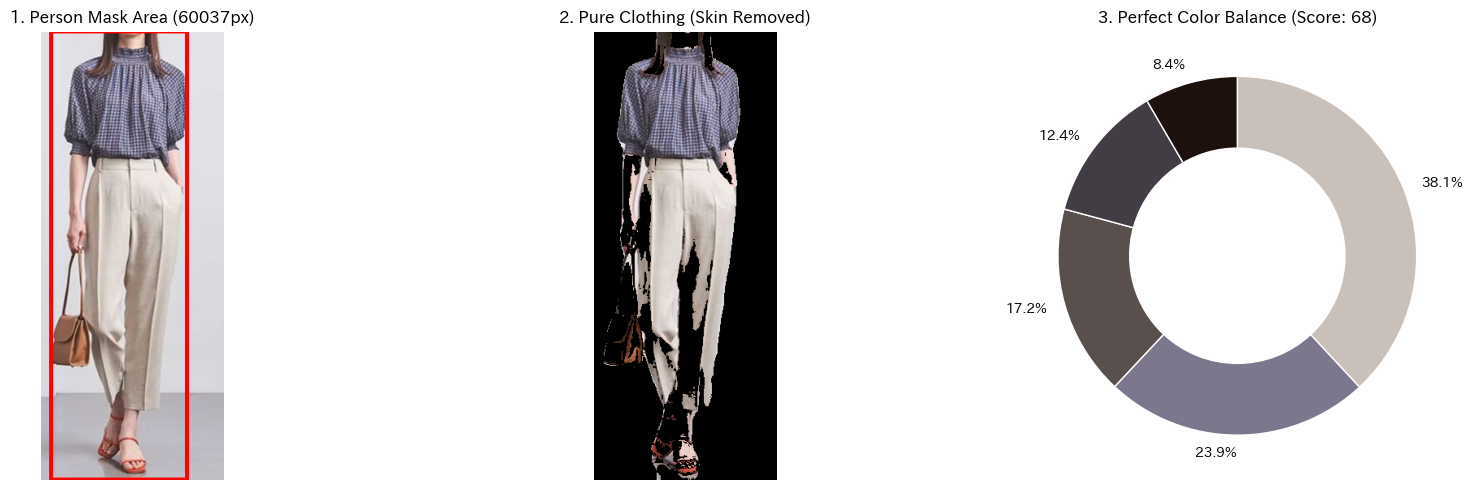

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
import urllib.request
import os
from google.colab import files

def analyze_perfect_color_balance():
    print("【1】服装の写真をアップロードしてください。")
    uploaded = files.upload()

    if not uploaded:
        print("ファイルがアップロードされませんでした。")
        return

    file_name = list(uploaded.keys())[0]
    file_bytes = np.frombuffer(uploaded[file_name], np.uint8)
    img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    height, width = img_rgb.shape[:2]
    max_size = 600
    if max(height, width) > max_size:
        scale = max_size / max(height, width)
        img_rgb = cv2.resize(img_rgb, (int(width * scale), int(height * scale)))
        height, width = img_rgb.shape[:2]

    model_path = "selfie_segmenter.tflite"
    if not os.path.exists(model_path):
        print("モデルファイルをダウンロード中...")
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/mediapipe-models/image_segmenter/selfie_segmenter/float16/latest/selfie_segmenter.tflite",
            model_path
        )
        print("ダウンロード完了")

    print("\n【2】AI（MediaPipe）で人物領域を抽出中...")
    from mediapipe.tasks import python
    from mediapipe.tasks.python import vision

    options = vision.ImageSegmenterOptions(
        base_options=python.BaseOptions(model_asset_path=model_path),
        output_category_mask=False,
        output_confidence_masks=True
    )

    with vision.ImageSegmenter.create_from_options(options) as segmenter:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        segmentation_result = segmenter.segment(mp_image)
        confidence_mask = np.squeeze(segmentation_result.confidence_masks[0].numpy_view())
        person_mask = (confidence_mask > 0.5).astype(np.uint8)

    print("【3】肌色を除外中...")
    img_hsv_init = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    lower_skin = np.array([0, 45, 80], dtype=np.uint8)
    upper_skin = np.array([22, 140, 240], dtype=np.uint8)
    skin_mask = cv2.inRange(img_hsv_init, lower_skin, upper_skin)
    pure_clothing_mask = cv2.bitwise_and(person_mask, cv2.bitwise_not(skin_mask // 255))
    img_pure_clothing = img_rgb * pure_clothing_mask[:, :, np.newaxis]

    print("【4】ポーズ補正中...")
    y_indices, x_indices = np.where(person_mask > 0)
    if len(y_indices) > 0:
        ymin, ymax = np.min(y_indices), np.max(y_indices)
        xmin, xmax = np.min(x_indices), np.max(x_indices)
        person_area = int(np.sum(person_mask))
    else:
        person_area = width * height
        ymin, ymax, xmin, xmax = 0, height, 0, width

    img_blurred = cv2.GaussianBlur(img_pure_clothing, (15, 15), 0)
    img_hsv = cv2.cvtColor(img_blurred, cv2.COLOR_RGB2HSV)
    pixels = np.float32(img_hsv.reshape((-1, 3)))
    K = 6
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixels, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    labels = labels.flatten()
    counts = np.bincount(labels)
    sorted_indices = np.argsort(counts)[::-1]

    def rgb_to_color_name(rgb):
        r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])
        hsv = cv2.cvtColor(np.uint8([[[r, g, b]]]), cv2.COLOR_RGB2HSV)[0][0]
        h, s, v = int(hsv[0]), int(hsv[1]), int(hsv[2])
        if s < 15:
            if v < 80:    return "ブラック"
            elif v < 200: return "グレー"
            else:         return "ホワイト"
        if s < 80:
            if h < 30 or h >= 160: return "ベージュ"
            elif h < 85:           return "カーキ"
            else:                  return "グレー"
        if h < 10 or h >= 170: return "レッド"
        elif h < 20:  return "オレンジ"
        elif h < 40:  return "イエロー"
        elif h < 85:  return "グリーン"
        elif h < 130: return "ブルー"
        elif h < 150: return "パープル"
        else:         return "ブラウン" if v < 140 else "ピンク"

    extracted_colors = []
    for idx in sorted_indices:
        hsv_color = np.uint8([[centers[idx]]])
        rgb_color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2RGB)[0][0]
        if rgb_color[0] < 20 and rgb_color[1] < 20 and rgb_color[2] < 20:
            continue
        percentage = (counts[idx] / person_area) * 100
        extracted_colors.append({'rgb': rgb_color, 'percentage': percentage, 'name': rgb_to_color_name(rgb_color)})

    total = sum([c['percentage'] for c in extracted_colors])
    for c in extracted_colors:
        c['percentage'] = (c['percentage'] / total) * 100

    while len(extracted_colors) < 3:
        extracted_colors.append({'rgb': np.array([0,0,0]), 'percentage': 0.0, 'name': '―'})

    p1, p2, p3 = extracted_colors[0]['percentage'], extracted_colors[1]['percentage'], extracted_colors[2]['percentage']
    diff = abs(p1 - 70) + abs(p2 - 25) + abs(p3 - 5)
    score = max(0, int(100 - (diff * 0.7)))

    if score >= 80:
        score_comment = "優秀！バランスの取れたコーデです"
    elif score >= 60:
        score_comment = "良好！もう少し調整するとさらに良くなります"
    elif score >= 40:
        score_comment = "もう一工夫でバランスが上がります"
    else:
        score_comment = "色数を絞るとまとまりが出ます"

    advice_lines = []
    if p1 < 60:
        advice_lines.append(f"・{extracted_colors[0]['name']}をもっと増やしてメインカラーを強調しましょう（目安70%）")
    elif p1 > 80:
        advice_lines.append(f"・{extracted_colors[0]['name']}が多すぎます。サブカラーを足してみましょう")
    if p2 < 15:
        advice_lines.append(f"・{extracted_colors[1]['name']}などのサブカラーをもう少し取り入れると奥行きが出ます（目安25%）")
    if extracted_colors[2]['percentage'] < 3:
        advice_lines.append("・アクセントカラーが少なすぎます。小物や差し色で引き締めましょう（目安5%）")
    if not advice_lines:
        advice_lines.append("・このままのバランスを維持しましょう！")

    print("\n" + "="*35)
    print("    あなたのコーデ診断結果")
    print("="*35)
    print(f"スコア: {score}点 / 100点  {score_comment}")
    print()
    roles = ["メインカラー", "サブカラー  ", "アクセント  "]
    for i, c in enumerate(extracted_colors[:3]):
        print(f"【{roles[i]}】{c['name']}系  ({c['percentage']:.1f}%)")
    print()
    print("💡 アドバイス")
    for line in advice_lines:
        print(line)
    print("="*35)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    img_mask_visualized = img_rgb.copy()
    cv2.rectangle(img_mask_visualized, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3)
    axes[0].imshow(img_mask_visualized)
    axes[0].set_title(f"1. Person Mask Area ({person_area}px)")
    axes[0].axis('off')

    axes[1].imshow(img_pure_clothing)
    axes[1].set_title("2. Pure Clothing (Skin Removed)")
    axes[1].axis('off')

    colors_hex = [f'#{c["rgb"][0]:02x}{c["rgb"][1]:02x}{c["rgb"][2]:02x}' for c in extracted_colors if c['percentage'] > 0]
    labels_pie = [f"{c['percentage']:.1f}%" for c in extracted_colors if c['percentage'] > 0]
    sizes = [c['percentage'] for c in extracted_colors if c['percentage'] > 0]
    axes[2].pie(sizes, labels=labels_pie, colors=colors_hex, startangle=90, counterclock=False,
                wedgeprops={'width': 0.4, 'edgecolor': 'white'})
    axes[2].set_title(f"3. Perfect Color Balance (Score: {score})")

    plt.tight_layout()
    plt.show()

analyze_perfect_color_balance()